# Weight `abstraction:IsAComponentOf` edges in the pathway-centered abstraction of BioPAX Reactome

2841 IsAComponentOf relationships to weight

2825 pathway nodes

In [1]:
import pandas as pd
import math
import networkx as nx
import os
import subprocess
import time
from SPARQLWrapper import SPARQLWrapper, JSON, CSV, N3, XML, TURTLE
import rdflib
import re
import IPython
import matplotlib.pyplot as plt
import numpy as np
import statistics

In [2]:
def create_networkx_graph(abstraction):
    # Créer le graphe en gardant le type d'interaction comme attribut
    PathwayAbstractionGraph = nx.from_pandas_edgelist(
        abstraction,
        source="subPathwayID",
        target="pathwayID",
        edge_attr="interaction",
        create_using=nx.MultiDiGraph()
    )
    print(f"Pathway abstraction loaded in networkx: {PathwayAbstractionGraph}")
    return PathwayAbstractionGraph


def extract_pathways(abstraction):
    return list(set(abstraction["subPathwayID"]).union(set(abstraction["pathwayID"])))

In [3]:
IsAComponentOf = pd.read_csv("../Results/ReactomeHomoSapiens94Abstractions/ReactomeHomoSapiens94_IsAComponentOf.csv", sep=",", header=0)
print(IsAComponentOf.head())

    subPathwayID                 interaction      pathwayID
0  R-HSA-8877627  abstraction:IsAComponentOf  R-HSA-6806667
1  R-HSA-6806664  abstraction:IsAComponentOf  R-HSA-6806667
2   R-HSA-975634  abstraction:IsAComponentOf  R-HSA-6806667
3  R-HSA-1296041  abstraction:IsAComponentOf  R-HSA-1296059
4   R-HSA-190241  abstraction:IsAComponentOf  R-HSA-5654738


## Resnik similarity

The information content of a pathway X (Resnik formula)

$ IC(X) = -log(\frac{|I(X)|}{|I(T)|}) $

where $I(X)$ is the number of direct and undirect descendants of pathway X and $I(T)$ is the total number of pathways

Resnik similarity between pathway X and pathway Y

$ sim(X,Y) = IC(MICA(X,Y)) $ where $MICA$ is the Most Informative Common Ancestor of pathway X and pathway Y 

In [11]:
def  information_content(NbDescPathway , NbPathways):
    return -math.log(math.fabs(NbDescPathway)/math.fabs(NbPathways)) 

def  find_ancestors_and_descendants(G, node, interaction):
    filtered_edges = [(u, v) for u, v, attr in G .edges(data =True) if attr.get("interaction") == interaction]
    subgraph = nx.DiGraph()
    subgraph.add_edges_from(filtered_edges)
    if node  in subgraph: 
        #Since edges are child->parent, we need to reverse the graph to find descendants 
        reversed_subgraph = subgraph.reverse()
        ancestors = nx.ancestors(reversed_subgraph, node)
        descendants = nx.descendants(reversed_subgraph, node)
        return ancestors, descendants
    else:
        return set(), set()

def  find_mica(G , Pathway1 , Pathway2 ):
    ancestors1, _ = find_ancestors_and_descendants(G, Pathway1, "abstraction:IsAComponentOf")
    ancestors2, _ = find_ancestors_and_descendants(G, Pathway2, "abstraction:IsAComponentOf")
    common_ancestors = list(set(ancestors1) & set(ancestors2))
    if common_ancestors:
        maxIC = 0
        mica = None
        for ancestor in common_ancestors:
            _, desc = find_ancestors_and_descendants(G , ancestor, "abstraction:IsAComponentOf")
            IC = information_content(len(desc), len(G .nodes()))
            if IC > maxIC:
                maxIC = IC
                mica = ancestor
        return mica
    return None 

def  create_dico_IC_pathways(abstraction):
    G = create_networkx_graph(abstraction)
    pathways = extract_pathways(abstraction)
    dicoIC = {}
    for pathway in pathways:
        _, desc = find_ancestors_and_descendants(G, pathway, "abstraction:IsAComponentOf")
        if len(desc) != 0:
            IC = information_content(len(desc), len(G.nodes()))
        else:
            IC = 0
        dicoIC[pathway] = IC
    nodeTable = pd.DataFrame({"Pathway": dicoIC.keys(), "IC": dicoIC.values()})
    return dicoIC, nodeTable 

def  resnik_similarity(G , node1 , node2):
    mica = find_mica(G , node1 , node2)
    if mica:
        _, desc = find_ancestors_and_descendants(G , mica, "abstraction:IsAComponentOf")
        return information_content(len(desc), len(G .nodes()))
    return 0 

def  create_dico_similarity(abstraction):
    G = create_networkx_graph(abstraction)
    dicoEdges = {}
    for idx, row in abstraction.iterrows():
        key = f"{row[0]} (abstraction:IsAComponentOf) {row[2]}"
        sim = resnik_similarity(G, row[0], row[2])
        dicoEdges[key] = sim
    edgeTable = pd.DataFrame({"shared name": dicoEdges.keys(), "weight": dicoEdges.values()})
    return dicoEdges, edgeTable   

In [5]:
dicoIC, nodeTable = create_dico_IC_pathways(IsAComponentOf)
print("")
print(f"dico IC: {dicoIC}") 

dicoSim, edgeTable = create_dico_similarity(IsAComponentOf)
print("")
print(f"dico Resnik similarity: {dicoSim}") 

Pathway abstraction loaded in networkx: MultiDiGraph with 2825 nodes and 2841 edges

dico IC: {'R-HSA-9909505': 0, 'R-HSA-1461973': 7.253116463020596, 'R-HSA-2023837': 0, 'R-HSA-9670613': 0, 'R-HSA-427601': 0, 'R-HSA-157118': 5.001824664414101, 'R-HSA-9026519': 0, 'R-HSA-140834': 0, 'R-HSA-2979096': 0, 'R-HSA-209560': 0, 'R-HSA-9026766': 0, 'R-HSA-9945266': 7.946263643580541, 'R-HSA-5652227': 0, 'R-HSA-5619077': 0, 'R-HSA-9657050': 0, 'R-HSA-9637679': 7.946263643580541, 'R-HSA-442755': 5.461356993792541, 'R-HSA-9927020': 0, 'R-HSA-166020': 0, 'R-HSA-3311021': 0, 'R-HSA-9759194': 5.749039066244322, 'R-HSA-5654720': 0, 'R-HSA-5663084': 4.362744705124431, 'R-HSA-209563': 0, 'R-HSA-420029': 0, 'R-HSA-112308': 0, 'R-HSA-9694548': 0, 'R-HSA-350054': 0, 'R-HSA-448424': 5.749039066244322, 'R-HSA-376172': 0, 'R-HSA-8941858': 0, 'R-HSA-1650814': 7.946263643580541, 'R-HSA-1660516': 0, 'R-HSA-879518': 0, 'R-HSA-193807': 0, 'R-HSA-210455': 0, 'R-HSA-390522': 0, 'R-HSA-9918436': 0, 'R-HSA-9762292': 

/tmp/ipykernel_6412/3804520448.py:58: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  key = f"{row[0]} (abstraction:IsAComponentOf) {row[2]}"
/tmp/ipykernel_6412/3804520448.py:59: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sim = resnik_similarity(G, row[0], row[2])



dico Resnik similarity: {'R-HSA-8877627 (abstraction:IsAComponentOf) R-HSA-6806667': 4.810769427651391, 'R-HSA-6806664 (abstraction:IsAComponentOf) R-HSA-6806667': 4.810769427651391, 'R-HSA-975634 (abstraction:IsAComponentOf) R-HSA-6806667': 4.810769427651391, 'R-HSA-1296041 (abstraction:IsAComponentOf) R-HSA-1296059': 6.336825731146441, 'R-HSA-190241 (abstraction:IsAComponentOf) R-HSA-5654738': 4.185063527886979, 'R-HSA-5654696 (abstraction:IsAComponentOf) R-HSA-5654738': 4.185063527886979, 'R-HSA-6803529 (abstraction:IsAComponentOf) R-HSA-5654738': 4.185063527886979, 'R-HSA-5654727 (abstraction:IsAComponentOf) R-HSA-5654738': 4.185063527886979, 'R-HSA-9705683 (abstraction:IsAComponentOf) R-HSA-9694516': 4.0961160418704825, 'R-HSA-9772573 (abstraction:IsAComponentOf) R-HSA-9694516': 4.0961160418704825, 'R-HSA-9772572 (abstraction:IsAComponentOf) R-HSA-9694516': 4.0961160418704825, 'R-HSA-9672393 (abstraction:IsAComponentOf) R-HSA-9662001': 5.17367492134076, 'R-HSA-9672391 (abstractio

In [26]:
weighted_graph = pd.DataFrame(columns=['source', 'interaction', 'target', 'weight'])
counter_rows = 0
for item, row in IsAComponentOf.iterrows():
    weighted_graph.at[counter_rows, 'source'] = row[0]
    weighted_graph.at[counter_rows, 'interaction'] = row[1]
    weighted_graph.at[counter_rows, 'target'] = row[2]
    key = f'{str(row[0])} (abstraction:IsAComponentOf) {str(row[2])}'
    weight = dicoSim[key]
    weighted_graph.at[counter_rows, 'weight'] = weight
    counter_rows += 1

weighted_graph.to_csv("../Results/ReactomeHomoSapiens94WeightedAbstractions/ReactomeHomoSapiens94_IsAComponentOf_Resnik.csv", sep=",", header=True, index=False)

/tmp/ipykernel_20352/1791770883.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  weighted_graph.at[counter_rows, 'source'] = row[0]
/tmp/ipykernel_20352/1791770883.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  weighted_graph.at[counter_rows, 'interaction'] = row[1]
/tmp/ipykernel_20352/1791770883.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  weighted_graph.at[counter_rows, 'target'] = row[2]
/tmp/ipykernel_20352/17917

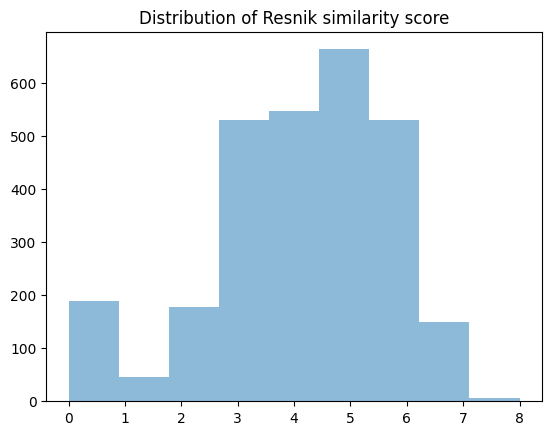

In [7]:
bins = np.linspace(0, 8, 10)
plt.hist(dicoSim.values(), bins=bins, alpha=0.5)
plt.title("Distribution of Resnik similarity score")
plt.show()

## Lin similarity

In [33]:
G = create_networkx_graph(IsAComponentOf)
def compute_lin_sim(abstraction, pathway1, pathway2):
    nb_nodes = len(abstraction.nodes())
    mica = find_mica(abstraction, pathway1, pathway2)
    _, desc_pathway1 = find_ancestors_and_descendants(abstraction, pathway1, interaction="abstraction:IsAComponentOf")
    _, desc_pathway2 = find_ancestors_and_descendants(abstraction, pathway2, interaction="abstraction:IsAComponentOf")
    if len(desc_pathway1) != 0:
        IC_pathway1 = information_content(len(desc_pathway1), nb_nodes)
    else:
        IC_pathway1 = 0
    if len(desc_pathway2) != 0:
        IC_pathway2 = information_content(len(desc_pathway2), nb_nodes)
    else:
        IC_pathway2 = 0
    if (IC_pathway1 + IC_pathway1) != 0 and mica:
        _, desc_mica = find_ancestors_and_descendants(abstraction, mica, interaction="abstraction:IsAComponentOf")
        IC_mica = information_content(len(desc_mica), nb_nodes)
        return (2*IC_mica) / (IC_pathway1 + IC_pathway2)
    else:
        return 0


dico_sim_lin = dict()
weighted_graph = pd.DataFrame(columns=['source', 'interaction', 'target', 'weight'])
counter_rows = 0
for item, row in IsAComponentOf.iterrows():
    weighted_graph.at[counter_rows, 'source'] = row[0]
    weighted_graph.at[counter_rows, 'interaction'] = row[1]
    weighted_graph.at[counter_rows, 'target'] = row[2]
    key = f'{str(row[0])} (abstraction:IsAComponentOf) {str(row[2])}'
    weight = compute_lin_sim(abstraction=G, pathway1=row[0], pathway2=row[2])
    weighted_graph.at[counter_rows, 'weight'] = weight
    dico_sim_lin[key] = weight
    counter_rows += 1

weighted_graph.to_csv("../Results/ReactomeHomoSapiens94WeightedAbstractions/ReactomeHomoSapiens94_IsAComponentOf_Lin.csv", sep=",", header=True, index=False)

Pathway abstraction loaded in networkx: MultiDiGraph with 2825 nodes and 2841 edges


/tmp/ipykernel_6412/2220752614.py:27: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  weighted_graph.at[counter_rows, 'source'] = row[0]
/tmp/ipykernel_6412/2220752614.py:28: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  weighted_graph.at[counter_rows, 'interaction'] = row[1]
/tmp/ipykernel_6412/2220752614.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  weighted_graph.at[counter_rows, 'target'] = row[2]
/tmp/ipykernel_6412/222075

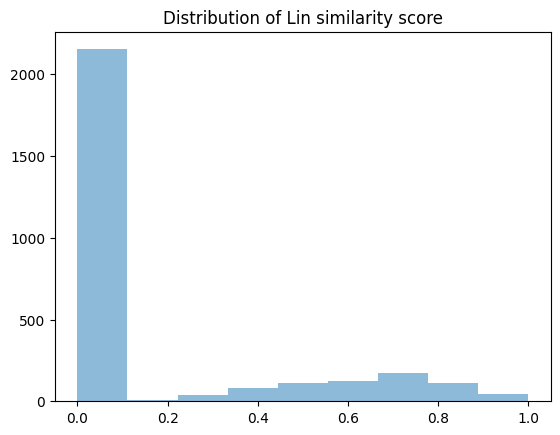

In [36]:
bins = np.linspace(0, 1, 10)
plt.hist(dico_sim_lin.values(), bins=bins, alpha=0.5)
plt.title("Distribution of Lin similarity score")
plt.show()

## Rada similarity